# Figure 5 motif analysis: 


### 1. Motif Contribution Score Analysis
This section analyzes the contribution scores of discovered motifs within the synthetic promoter sequences.
1.  **Data Loading**: Loads FIMO motif scan results (`fimo_target_seq.tsv`) and pre-calculated contribution scores (`contribution_scores.h5`).
2.  **Calculation**: Calculates the mean contribution score for each of the 13 discovered motifs (Seqlet0-12) by aggregating scores from instances where the motifs appear.
3.  **Visualization**: Generates a heatmap comparing "Canonical motifs" (known plant motifs) vs. "Newly-found motifs", showing their relative importance in the model's decision making.

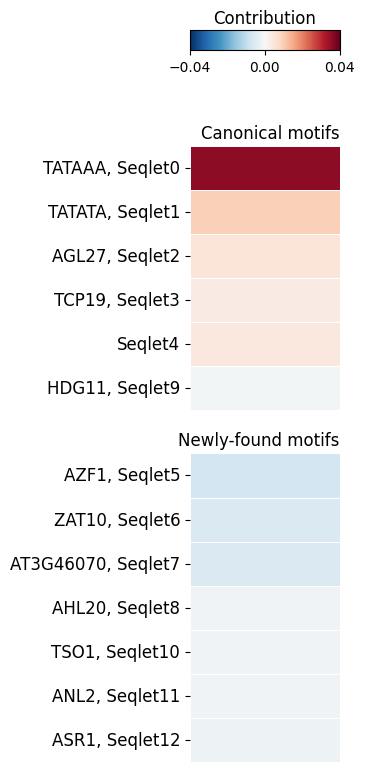

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import h5py
from collections import OrderedDict
import matplotlib.gridspec as gridspec

# 1. Load Data
fimo_target = pd.read_csv('./data_for_plot/fimo_target_seq.tsv', sep='\t')

# Define MEME file path (used to get Motif names or order)
meme_file = "./data_for_plot/targetgan.meme"
motif_pwm_data = {}
with open(meme_file, "r") as file:
    current_motif = None
    for line in file:
        line = line.strip()
        if line.startswith("MOTIF"):
            parts = line.split()
            current_motif = parts[1]
            motif_pwm_data[current_motif] = []
        elif current_motif and line and all(c.isdigit() or c == '.' or c.isspace() for c in line):
            pwm_row = list(map(float, line.split()))
            motif_pwm_data[current_motif].append(pwm_row)

# Load contribution scores
task_to_scores = OrderedDict()
task_to_hyp_scores = OrderedDict()
f = h5py.File("./data_for_plot/contribution_scores.h5", "r")
tasks = f["contrib_scores"].keys() # 'task0'

# Read data
for task in tasks:
    task_to_scores[task] = [np.array(x) for x in f['contrib_scores'][task][:]]
    task_to_hyp_scores[task] = [np.array(x) for x in f['hyp_contrib_scores'][task][:]]

hyp_scores = np.array(task_to_hyp_scores['task0'])

# 2. Calculate Motif Contribution
over_contribution_norm = []
for motif_idx in range(13):
    motif_id = f'motif_pfm{motif_idx}'
    temp = fimo_target[fimo_target.motif_id == motif_id]
    temp.reset_index(drop=True, inplace=True)
    
    all_contri_norm = []
    
    if temp.shape[0] > 0:
        for i in range(temp.shape[0]):
            temp_sequence_name = int(temp.sequence_name[i])
            temp_start = int(temp.start[i])
            temp_stop = int(temp.stop[i])
            
            # Handle positive/negative strands
            if temp.strand[i] == '+':
                temp_hyp_scores = hyp_scores[temp_sequence_name][temp_start-1:temp_stop, :]
            else:
                temp_hyp_scores = hyp_scores[temp_sequence_name][::-1, ::-1][temp_start-1:temp_stop, :]
            
            # Calculate mean tanh contribution
            temp_contribution_norm = np.mean(np.tanh(temp_hyp_scores))
            all_contri_norm.append(temp_contribution_norm)
        
        over_contribution_norm.append(np.mean(all_contri_norm))
    else:
        over_contribution_norm.append(0.0) # If no match, set to 0

over_contribution_norm = np.array(over_contribution_norm)

# 3. Define Labels and Groups
# Full label map
label_map = {
    0: "TATAAA, Seqlet0",
    1: "TATATA, Seqlet1",
    2: "AGL27, Seqlet2",
    3: "TCP19, Seqlet3",
    4: "Seqlet4",
    5: "AZF1, Seqlet5",
    6: "ZAT10, Seqlet6",
    7: "AT3G46070, Seqlet7",
    8: "AHL20, Seqlet8",
    9: "HDG11, Seqlet9",
    10: "TSO1, Seqlet10",
    11: "ANL2, Seqlet11",
    12: "ASR1, Seqlet12"
}

# Save seqlet contribution as dictionary
seqlet_contribution_dict = {label_map[i]: over_contribution_norm[i] for i in range(13)}
with open("./data_for_plot/seqlet_scores.txt", "w", encoding="utf-8") as f:
    for key, value in seqlet_contribution_dict.items():
        f.write(f"{key}: {value}\n")

# Define indices for two groups
canonical_indices = [0, 1, 2, 3, 4, 9]
newly_found_indices = [5, 6, 7, 8, 10, 11, 12]

# Prepare plot data
def get_heatmap_data(indices, scores, labels_map):
    data = scores[indices].reshape(-1, 1)
    labels = [labels_map[i] for i in indices]
    return data, labels

data_canonical, labels_canonical = get_heatmap_data(canonical_indices, over_contribution_norm, label_map)
data_new, labels_new = get_heatmap_data(newly_found_indices, over_contribution_norm, label_map)

# 4. Plotting
# Set layout: narrower figure (3 inches width), 2 rows
fig = plt.figure(figsize=(3, 8))

# Configure GridSpec with manual margins to prevent overlaps
# Left margin larger (0.45) for long Y-axis labels
# Top margin (0.85 -> 0.82) to leave MORE space for colorbar and title
gs = gridspec.GridSpec(2, 1, height_ratios=[len(canonical_indices), len(newly_found_indices)], hspace=0.15)
gs.update(left=0.45, right=0.95, top=0.82, bottom=0.05)

# Colorbar range and colormap
vmin, vmax = -0.04, 0.04
cmap = "RdBu_r" 

# Plot Upper Part (Canonical motifs)
ax1 = plt.subplot(gs[0])
sns.heatmap(data_canonical, ax=ax1, cmap=cmap, vmin=vmin, vmax=vmax,
            annot=False, cbar=False, linewidths=0.5, linecolor='white')
ax1.set_yticklabels(labels_canonical, rotation=0, fontsize=12)
ax1.set_xticks([]) 
# Title aligned to right, slightly padded to not hit colorbar labels if any
ax1.set_title("Canonical motifs", loc='right', fontsize=12, pad=6)

# Plot Lower Part (Newly-found motifs)
ax2 = plt.subplot(gs[1])
sns.heatmap(data_new, ax=ax2, cmap=cmap, vmin=vmin, vmax=vmax,
            annot=False, cbar=False, linewidths=0.5, linecolor='white')
ax2.set_yticklabels(labels_new, rotation=0, fontsize=12)
ax2.set_xticks([])
ax2.set_title("Newly-found motifs", loc='right', fontsize=12, pad=6)

# Shared Colorbar at the top
# Position: [left, bottom, width, height] relative to figure
# Aligned with the heatmap area (from 0.45 to 0.95, width=0.5)
# Moved bottom from 0.92 -> 0.94 to push it up
cbar_ax = fig.add_axes([0.45, 0.94, 0.5, 0.025]) 
norm = plt.Normalize(vmin=vmin, vmax=vmax)
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax, orientation='horizontal')

# Move title to top of colorbar to avoid clashing with "Canonical motifs"
cbar.ax.set_title("Contribution", fontsize=12, pad=5)
# Set ticks to be clean
cbar.set_ticks([vmin, 0, vmax])
cbar.ax.tick_params(labelsize=10)

#plt.savefig('contribution_score_combined.svg', dpi=1000) 
plt.show()

### 2. Motif Usage Fraction
Comparison of motif usage frequencies between Synthetic Promoters (SP) and Native Promoters (NP).
1.  **Calculation**: Calculates the fraction of sequences containing each motif in the synthetic dataset ($N=55,296$) versus the native dataset ($N=76,851$).
2.  **Visualization**: Displays a divergent bar chart. The left panel shows usage in Synthetic Promoters (light gray), and the right panel shows usage in Native Promoters (dark gray), allowing for direct comparison of motif enrichment.

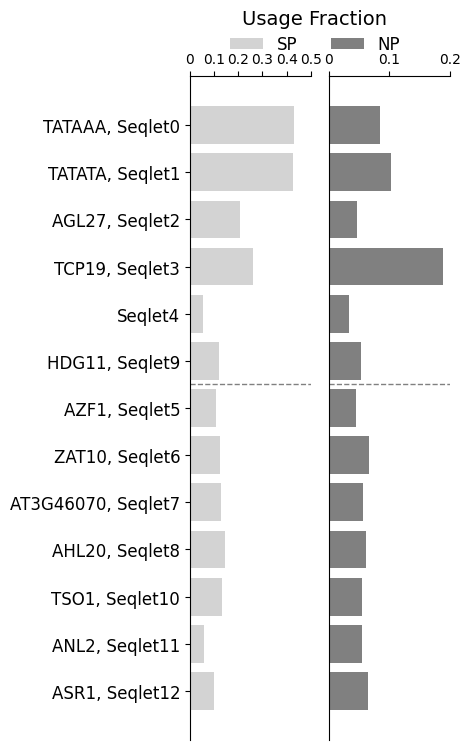

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch

# 1. Load Data
df_syn = pd.read_csv('./data_for_plot/fimo_target_seq.tsv', sep='\t')
df_nat = pd.read_csv('./data_for_plot/fimo_nat.tsv', sep='\t')

n_syn = 55296
n_nat = 76851

# 2. Calculate Usage Fractions
def calculate_usage_fraction(df, total_seqs, num_motifs=13):
    fractions = []
    for i in range(num_motifs):
        motif_id = f'motif_pfm{i}'
        unique_count = df[df['motif_id'] == motif_id]['sequence_name'].nunique()
        fractions.append(unique_count / total_seqs)
    return np.array(fractions)

frac_syn = calculate_usage_fraction(df_syn, n_syn)
frac_nat = calculate_usage_fraction(df_nat, n_nat)

# 3. Organize Data
label_map = {
    0: "TATAAA, Seqlet0",
    1: "TATATA, Seqlet1",
    2: "AGL27, Seqlet2",
    3: "TCP19, Seqlet3",
    4: "Seqlet4",
    5: "AZF1, Seqlet5",
    6: "ZAT10, Seqlet6",
    7: "AT3G46070, Seqlet7",
    8: "AHL20, Seqlet8",
    9: "HDG11, Seqlet9",
    10: "TSO1, Seqlet10",
    11: "ANL2, Seqlet11",
    12: "ASR1, Seqlet12"
}

canonical_indices = [0, 1, 2, 3, 4, 9]
newly_found_indices = [5, 6, 7, 8, 10, 11, 12]
ordered_indices = canonical_indices + newly_found_indices

labels = [label_map[i] for i in ordered_indices]
values_syn = frac_syn[ordered_indices]
values_nat = frac_nat[ordered_indices]

# 4. Plotting
fig = plt.figure(figsize=(5, 8))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.15)

y_pos = np.arange(len(labels))[::-1]
bar_height = 0.8

# Plot SP (Synthetic) - Left Panel
ax1 = plt.subplot(gs[0])
ax1.barh(y_pos, values_syn, height=bar_height, color='lightgray')
ax1.set_yticks(y_pos)
ax1.set_yticklabels(labels, fontsize=12)
ax1.set_xlim(0, 0.5) 
ax1.xaxis.tick_top()

# Use custom tick labels to avoid "0.0" and ensuring clean spacing
ticks_sp = [0, 0.1, 0.2, 0.3, 0.4, 0.5]
ax1.set_xticks(ticks_sp)
ax1.set_xticklabels(['0', '0.1', '0.2', '0.3', '0.4', '0.5'], fontsize=10)

ax1.spines['bottom'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.axhline(y=6.5, color='gray', linestyle='--', linewidth=1)

# Plot NP (Native) - Right Panel
ax2 = plt.subplot(gs[1])
ax2.barh(y_pos, values_nat, height=bar_height, color='gray')
ax2.set_yticks([]) 
ax2.set_xlim(0, 0.2) 
ax2.xaxis.tick_top()

# Use custom tick labels to avoid "0.0" collision
ticks_np = [0, 0.1, 0.2]
ax2.set_xticks(ticks_np)
ax2.set_xticklabels(['0', '0.1', '0.2'], fontsize=10)

ax2.spines['bottom'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(True) 
ax2.axhline(y=6.5, color='gray', linestyle='--', linewidth=1)

# Legend and Title
legend_elements = [Patch(facecolor='lightgray', label='SP'),
                   Patch(facecolor='gray', label='NP')]

fig.legend(handles=legend_elements, 
           loc='lower center', 
           bbox_to_anchor=(0.63, 0.90),
           ncol=2, 
           frameon=False, 
           fontsize=12,
           borderaxespad=0)

fig.text(0.63, 0.94, "Usage Fraction", ha='center', fontsize=14, va='bottom')

plt.subplots_adjust(top=0.88, left=0.38, right=0.90, bottom=0.05) 

#plt.savefig('usage_fraction.svg', dpi=1000)
plt.show()

### 3. Motif Co-occurrence Analysis
Analysis of how frequently pairs of motifs appear together in the same sequence.
1.  **Matrix Construction**: Builds binary presence/absence matrices for both SP and NP datasets and computes the co-occurrence frequency ($A^T A$).
2.  **Visualization**: Creates a combined triangular heatmap.
    *   **Lower Triangle (SP)**: Co-occurrence frequencies in Synthetic Promoters.
    *   **Upper Triangle (NP)**: Co-occurrence frequencies in Native Promoters.
    *   This layout facilitates checking if specific motif pairs are preferentially selected together (combinatorial regulation) in the generated sequences.

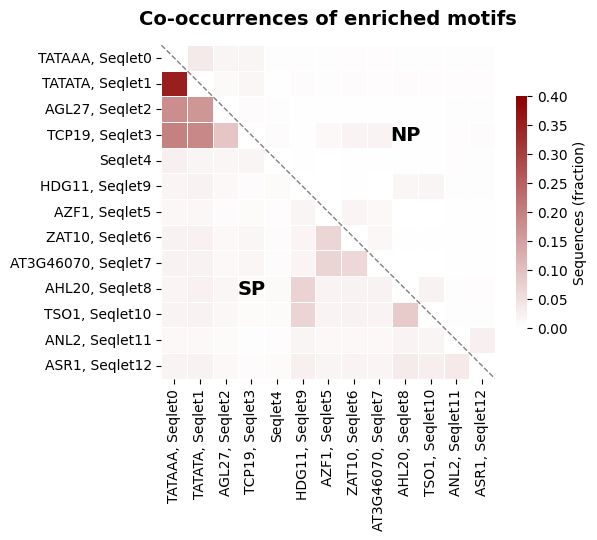

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# 1. Load Data
fimo_target = pd.read_csv('./data_for_plot/fimo_target_seq.tsv', sep='\t')
fimo_native = pd.read_csv('./data_for_plot/fimo_nat.tsv', sep='\t')

total_syn = 55296
total_nat = 76851

# 2. Count Motif Co-occurrences
def get_motif_counts_matrix(fimo_df, total_sequences, num_motifs=13):
    # Pre-allocate matrix
    motif_presence = np.zeros((total_sequences, num_motifs), dtype=int)
    
    # Filter out rows that are comments or invalid
    # Ensure 'motif_id' column contains strings and starts with 'motif_pfm'
    # This prevents errors if FIMO header lines are included in the CSV body
    valid_df = fimo_df[fimo_df['motif_id'].astype(str).str.startswith('motif_pfm')].copy()

    # Extract motif index
    # Safely convert to int
    valid_df['motif_idx'] = valid_df['motif_id'].apply(lambda x: int(str(x).split('motif_pfm')[-1]))
    valid_df['seq_idx'] = valid_df['sequence_name'].astype(int)
    
    # Fill matrix (vectorized assignment)
    # Filter valid indices just in case to prevent IndexErrors
    valid_rows = valid_df[(valid_df['seq_idx'] < total_sequences) & (valid_df['motif_idx'] < num_motifs)]
    motif_presence[valid_rows['seq_idx'], valid_rows['motif_idx']] = 1
            
    return motif_presence

binary_syn = get_motif_counts_matrix(fimo_target, total_syn)
binary_nat = get_motif_counts_matrix(fimo_native, total_nat)

# 3. Calculate Co-occurrence Frequencies
def get_cooccurrence_matrix(binary_matrix, total_count):
    # binary_matrix: (N, 13)
    # cooccurrence: (13, 13) = binary_matrix.T @ binary_matrix
    cooc_counts = binary_matrix.T @ binary_matrix
    # Normalize by total sequence count
    return cooc_counts / total_count

matrix_syn = get_cooccurrence_matrix(binary_syn, total_syn) # Lower triangle
matrix_nat = get_cooccurrence_matrix(binary_nat, total_nat) # Upper triangle

# 4. Construct Combined Matrix
# Label map definition
label_map = {
    0: "TATAAA, Seqlet0",
    1: "TATATA, Seqlet1",
    2: "AGL27, Seqlet2",
    3: "TCP19, Seqlet3",
    4: "Seqlet4",
    5: "AZF1, Seqlet5",
    6: "ZAT10, Seqlet6",
    7: "AT3G46070, Seqlet7",
    8: "AHL20, Seqlet8",
    9: "HDG11, Seqlet9",
    10: "TSO1, Seqlet10",
    11: "ANL2, Seqlet11",
    12: "ASR1, Seqlet12"
}

# Define indices for reordering
canonical_indices = [0, 1, 2, 3, 4, 9]
newly_found_indices = [5, 6, 7, 8, 10, 11, 12]
ordered_indices = canonical_indices + newly_found_indices
labels = [label_map[i] for i in ordered_indices]

# Reorder matrices efficiently using numpy indexing
# Create grid of new indices
idx_grid = np.ix_(ordered_indices, ordered_indices)
reordered_matrix_syn = matrix_syn[idx_grid]
reordered_matrix_nat = matrix_nat[idx_grid]

# Combine: Upper Triangle (Nat) + Lower Triangle (Syn)
# Use k=1 for upper triangle to exclude diagonal
# Use k=-1 for lower triangle to exclude diagonal
combined_matrix = np.triu(reordered_matrix_nat, k=1) + np.tril(reordered_matrix_syn, k=-1)
np.fill_diagonal(combined_matrix, 0) 

# 5. Plotting
fig, ax = plt.subplots(figsize=(6, 6))

colors = ["white", "darkred"]
custom_cmap = LinearSegmentedColormap.from_list("custom_bluered", colors)

# Mask diagonal
n_motifs = 13
mask = np.eye(n_motifs, dtype=bool)

# Plot Heatmap
sns.heatmap(
    combined_matrix,
    cmap=custom_cmap,
    square=True,
    annot=False,
    cbar_kws={"label": "Sequences (fraction)", "shrink": 0.5},
    vmax=0.4, 
    vmin=0.0,
    mask=mask,
    linecolor="white", 
    linewidths=0.5,
    xticklabels=labels,
    yticklabels=labels,
    ax=ax
)

# Diagonal Dashed Line
ax.plot([0, n_motifs], [0, n_motifs], ls="--", c="gray", linewidth=1)

# Add Text Labels "SP" and "NP"
# Coordinates (x, y) relative to data (0-12)
# SP (Lower triangle): x=3 (4th col), y=9 (10th row) -> [3.5, 9.5] centered
ax.text(3.5, 9.5, "SP", fontsize=14, fontweight='bold', ha='center', va='center')
# NP (Upper triangle): x=9 (10th col), y=3 (4th row) -> [9.5, 3.5] centered
ax.text(9.5, 3.5, "NP", fontsize=14, fontweight='bold', ha='center', va='center')

# Axis Title
ax.set_title("Co-occurrences of enriched motifs", fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
#plt.savefig('co_occurenece.svg', dpi=1000)
plt.show()

### 4. Global Motif Distribution Heatmap
Visualizes the occurrence of enriched motifs across the entire dataset of synthetic promoters, organized by their properties.
1.  **Data Processing**: Aggregates motif counts for each sequence.
2.  **Sorting**: Sequences are sorted hierarchically: primarily by their Target expression bin (Max $\to$ Min) and secondarily by predicted Promoter Strength.
3.  **Visualization**: A large-scale heatmap showing motif density across all 55,296 sequences. Vertical bands indicate specific motifs, and the sorting reveals how motif composition changes with target experession levels.

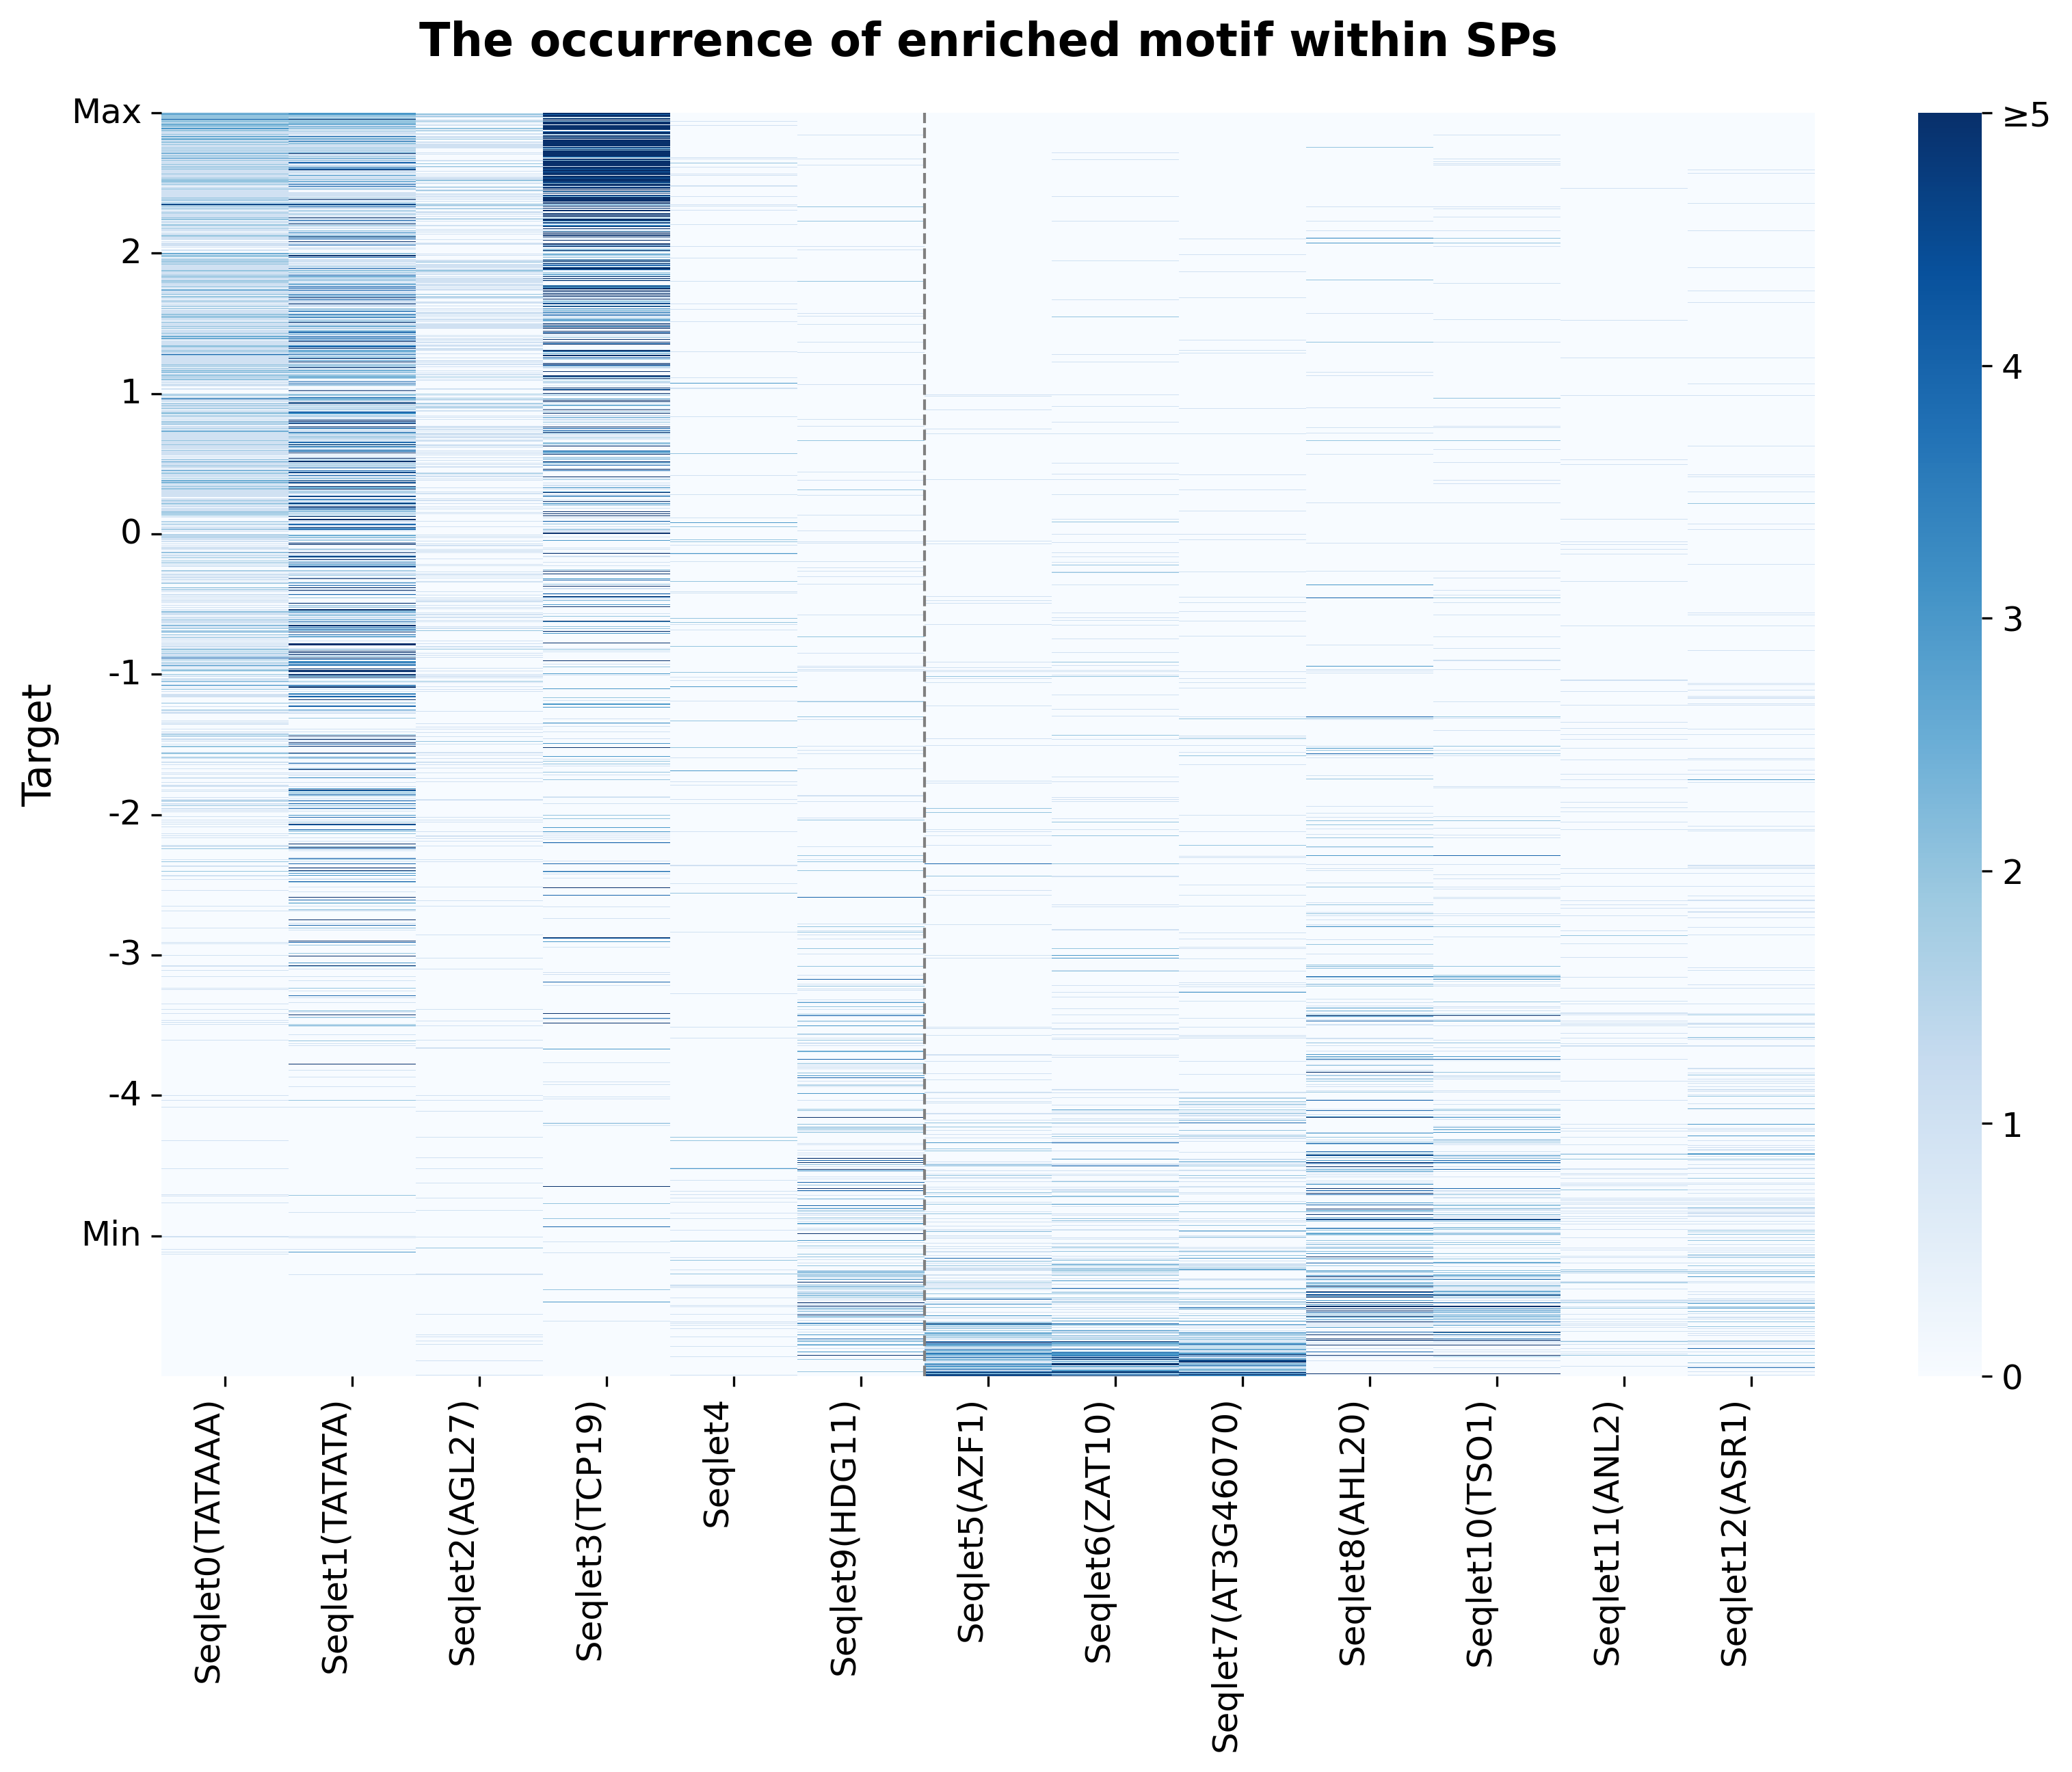

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1. Load Data
fimo_target = pd.read_csv('./data_for_plot/fimo_target_seq.tsv', sep='\t')
excel_path = '../data/targetgan_55296.xlsx'
all_seq = pd.read_excel(excel_path)

motif_counts = pd.DataFrame(0,index=[i for i in range(55296)],columns=['seqlet_%s'%i for i in range(13)])
for i in range(272416):
    s=fimo_target['motif_id'][i].split('motif_pfm')[-1]
    motif = 'seqlet_%s'%s
    seq = int(fimo_target['sequence_name'][i])
    motif_counts[motif][seq]+=1

col_names = list(motif_counts.sum(axis=0).sort_values(ascending=False).index)
motif_counts = motif_counts.loc[:,col_names]

# Clip values > 5
motif_counts[motif_counts>5] = 5

# Create combined DataFrame
motif_counts_with_names = pd.concat([all_seq['target'], all_seq['the predicted promoter strength'], motif_counts], axis=1)

# 1. Sort Rows: Target Order (Max->Min) + Promoter Strength (High->Low)
motif_counts_with_names['target_str'] = motif_counts_with_names['target'].astype(str).str.lower()
target_order_list = ['max', '2', '1', '0', '-1', '-2', '-3', '-4', 'min']
rank_map = {k: i for i, k in enumerate(target_order_list)}
motif_counts_with_names['target_rank'] = motif_counts_with_names['target_str'].map(rank_map).fillna(99)

motif_counts_with_names = motif_counts_with_names.sort_values(
    by=['target_rank', 'the predicted promoter strength'], 
    ascending=[True, False]
)

# 2. Reorder Columns: Specific Axis Order (0,1,2,3,4,9 then 5,6,7,8,10,11,12)
desired_indices = [0, 1, 2, 3, 4, 9, 5, 6, 7, 8, 10, 11, 12]
cols_seqlet = [f'seqlet_{i}' for i in desired_indices]
# Use the sorted dataframe for plotting
plot_data = motif_counts_with_names[cols_seqlet]

# Define Labels
x_labels = [
    'Seqlet0(TATAAA)', 'Seqlet1(TATATA)', 'Seqlet2(AGL27)', 'Seqlet3(TCP19)', 'Seqlet4', 'Seqlet9(HDG11)',
    'Seqlet5(AZF1)', 'Seqlet6(ZAT10)', 'Seqlet7(AT3G46070)', 'Seqlet8(AHL20)', 'Seqlet10(TSO1)', 'Seqlet11(ANL2)', 'Seqlet12(ASR1)'
]
y_labels = ['Max', '2', '1', '0', '-1', '-2', '-3', '-4', 'Min']
y_ticks = np.arange(0, 55296, 6144)

fig, ax = plt.subplots(figsize=(13, 8), dpi=300)
# Use plot_data (sorted) instead of motif_counts (unsorted)
sns.heatmap(plot_data, cmap='Blues', ax=ax, cbar_kws={'label': ''}, vmin=0, vmax=5)

# Customize X-axis
ax.set_xticks(np.arange(len(x_labels)) + 0.5)
ax.set_xticklabels(x_labels, rotation=90, ha='right', fontsize=12)

# Customize Y-axis
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labels, rotation=0, fontsize=12)

# Vertical Dashed Line (after 6th column, i.e., at x=6)
ax.axvline(x=6, color='gray', linestyle='--', linewidth=1)

# Title and Labels
ax.set_title("The occurrence of enriched motif within SPs", fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('Target', fontsize=14)
ax.set_xlabel('')

# Customize Colorbar
cbar = ax.collections[0].colorbar
cbar.set_ticks([0, 1, 2, 3, 4, 5])
cbar.set_ticklabels(['0', '1', '2', '3', '4', '≥5'])
cbar.ax.tick_params(labelsize=12)

plt.show()

### 5. Single Promoter Analysis (Case Study: SP358)
A deep dive into a specific synthetic promoter instance (SP358) to visualize its structure and functional elements.
1.  **Sequence Logo**: Visualizes the nucleotides of SP358 using a sequence logo, highlighting the motif instances.
2.  **DeepLIFT Tracks**: Aligns the sequence with its DeepLIFT contribution scores (importance profile).
3.  **Interpretation**: By stacking these plots, we can directly link high-importance regions (peaks in the score track) to specific sequence motifs (logos), verifying that the model attends to the expected regulatory elements.

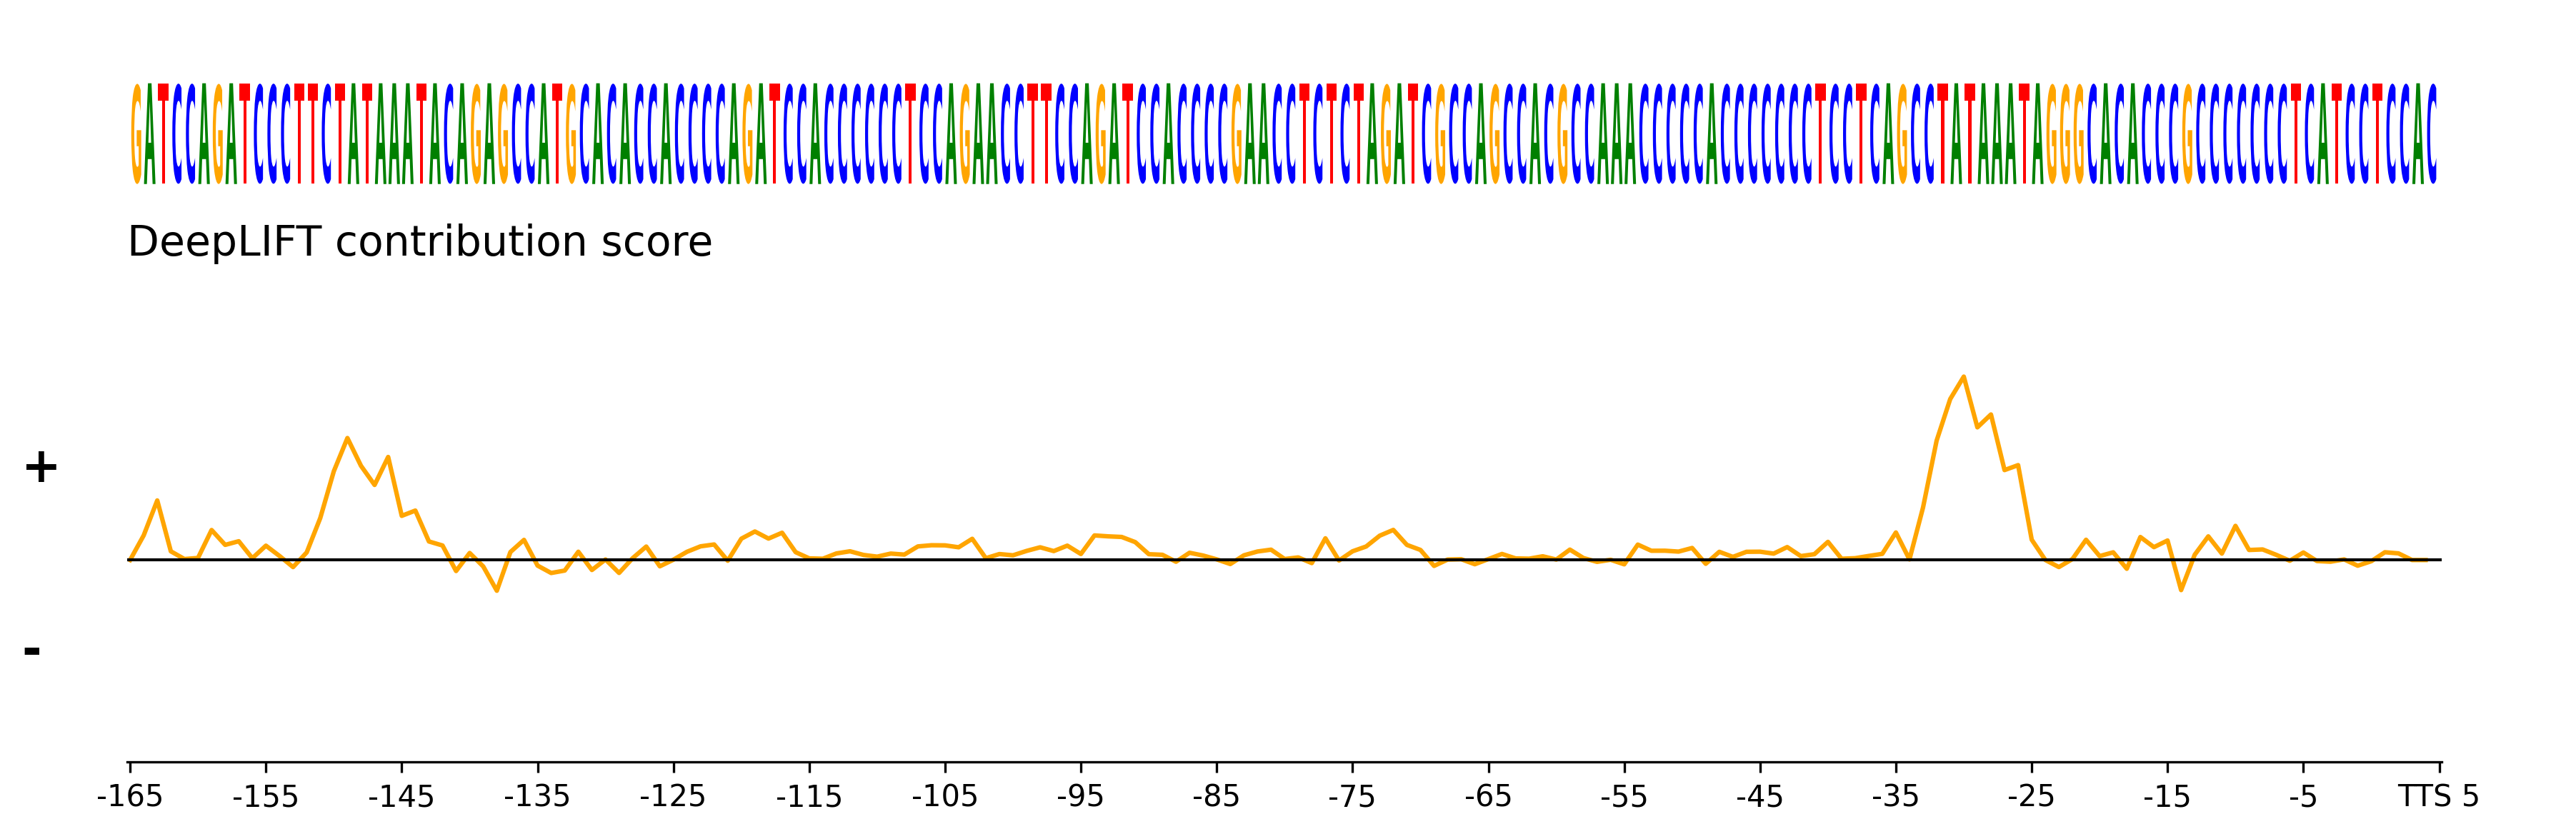

In [28]:
import numpy as np
import pandas as pd
import dmslogo
import tensorflow as tf
import matplotlib.pyplot as plt
import h5py
from collections import OrderedDict
import utils  

# 1. Setup Data
sp358 = 'GATCCAGATCCCTTCTATAAATACAGAGCCATGCACACCACCCCAGATCCACCCCCCTCCAGAACCTTCCAGATCCACCCCGAACCTCTCTAGATCGCCAGCCACGCCAAACCCCCACCCCCCCTCCTCAGCCTATAAATAGGGCACACCCGCCCCCCCTCATCCTCCAC'
STANDARD_NT = ['A','C','G','T']
DNA_COMPLEMENTS = {'A':'T', 'G':'C', 'T':'A', 'C':'G'}

# Try loading all_seq if not present
try:
    all_seq
except NameError:
    # If not defined in previous cells
    excel_path = '../data/targetgan_55296.xlsx'
    all_seq = pd.read_excel(excel_path)

# 2. Helper Functions
def dna2tensor(sequence_str):
    """
    Convert a DNA sequence to a one-hot encoded tensor using utils.one_hot_encode.
    Returns TensorFlow tensor of shape (4, L).
    """
    arr = utils.one_hot_encode(sequence_str).T
    return tf.convert_to_tensor(arr, dtype=tf.float32)

def tensor_to_pandas(in_tensor):
    data = []
    if isinstance(in_tensor, (tf.Tensor, tf.Variable)):
        my_array = in_tensor.numpy()
    elif hasattr(in_tensor, 'cpu'):
        my_array = in_tensor.cpu().numpy()
    else:
        my_array = in_tensor

    for nt, score_vec, color in zip(['A','C','G','T'], [ sub_a for sub_a in my_array ], ['green','blue','orange','red']):
         _ = [ data.append([j, nt, score, color]) for j, score in enumerate(score_vec)]
    return pd.DataFrame(data=data, columns=['site', 'letter', 'height','color'])

def matrix_to_dms(in_tensor, ax=None, y_max=None):
    motif = tensor_to_pandas(in_tensor)
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 2))
    
    # Use dmslogo to draw on the provided axis
    dmslogo.draw_logo(data=motif,
                      x_col='site',
                      letter_col='letter',
                      letter_height_col='height',
                      color_col='color',
                      ax=ax,
                      fixed_ymax=y_max)
    return ax

# 3. Load Scores
f = h5py.File("../modisco/scores.h5", "r")
tasks = f["contrib_scores"].keys() # 'task0'
task_to_scores = OrderedDict()
for task in tasks:
    task_to_scores[task] = [np.array(x) for x in f['contrib_scores'][task][:]]

scores = np.array(task_to_scores['task0'])

# 4. Get Data for SP358
seq_idx = int(all_seq[all_seq.sequence == sp358].index[0])
# Contribution profile: Sum over channels (A,C,G,T)
score_track = np.sum(scores[seq_idx], axis=1) 

# 5. Combined Plotting
# Adjusted layout: Increased hspace and figsize height to prevent title overlap
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 4), dpi=300, sharex=True, 
                               gridspec_kw={'height_ratios': [0.5, 2], 'hspace': 0.3})

# --- Top Plot: Sequence Logo ---
optimized_sequence = dna2tensor(sp358)
matrix_to_dms(optimized_sequence, ax=ax1, y_max=1)
ax1.axis('off') # Remove box and ticks for logo

# --- Bottom Plot: DeepLIFT Scores ---
ax2.plot(score_track, color='orange', linewidth=1.5)
ax2.axhline(y=0, color='black', linewidth=1)

# X-axis ticks customization (Match range -165 to +5)
seq_len = len(sp358) # 170
x_ticks = np.arange(0, seq_len + 1, 10)
x_labels = [str(val) for val in range(-165, 6, 10)]

# Handle label mismatch if lengths differ slightly due to range
if len(x_labels) > len(x_ticks):
    x_labels = x_labels[:len(x_ticks)]
elif len(x_ticks) > len(x_labels):
    x_ticks = x_ticks[:len(x_labels)]

# Set last label to "TTS +5"
if x_labels:
    x_labels[-1] = "TTS " + x_labels[-1] if not "TTS" in x_labels[-1] else x_labels[-1]
    # Or strictly "TTS +5"
    if x_labels[-1] == '5':
        x_labels[-1] = 'TTS +5'

ax2.set_xticks(x_ticks)
ax2.set_xticklabels(x_labels, fontsize=10)

# Style optimizations
ax2.set_title("DeepLIFT contribution score", loc='left', fontsize=14, pad=10)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.set_yticks([]) # Remove Y ticks

# Add polarity signs
y_limit = max(abs(score_track.min()), abs(score_track.max()))
ax2.set_ylim(-y_limit*1.1, y_limit*1.5) 
# Add + and - manually, position adjusting
ax2.text(-8, y_limit/2, '+', fontsize=16, fontweight='bold', va='center')
ax2.text(-8, -y_limit/2, '-', fontsize=16, fontweight='bold', va='center')

plt.subplots_adjust(left=0.05, right=0.95, top=0.9, bottom=0.1)
plt.show()